In [ ]:
#dependencias
import os
import sys
from pathlib import Path
import geopandas as gpd
import pandas as pd
import h3
from shapely.geometry import Polygon
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import DualMap


%store -r ruta

In [ ]:
# Cargamos el archivo que creamos en el otro notebook
red_vial = gpd.read_file(Path(ruta) / 'data' / 'data_generada' / 'red_vial_procesada.gpkg')

# Verificamos que traiga el CRS correcto
print(f"CRS recuperado: {red_vial.crs}")

CRS recuperado: EPSG:32719


In [5]:
# Función para H3
def hex_to_poly(h3_index):
    try:
        boundary_latlon = h3.cell_to_boundary(h3_index)
        boundary_lonlat = [(lon, lat) for lat, lon in boundary_latlon]
        return Polygon(boundary_lonlat)
    except:
        return None

def get_lanes(val):
    try:
        n = int(val)
        return max(1, n)
    except:
        return 1

def solve_greenshields(row):
    vf = row['velocidad_vf']
    kj = row['kj']
    q = row['flujo_q']
    
    if kj <= 1e-5: 
        return 0
        
    a = vf / kj
    b = -vf
    c = q
    
    delta = b**2 - 4*a*c
    
    if delta < 0:
        return kj / 2
    else:
        k_sol = (-b - np.sqrt(delta)) / (2*a)
        return k_sol

#PREPARACION DE DATOS DE MOVILIDAD
print("Procesando datos de movilidad...")
try:
    df_movilidad = pd.read_csv(Path(ruta) / 'data' / 'miercoles_rm.csv')
    
    hora_analisis = 18 
    df_hora = df_movilidad[df_movilidad['hora'] == hora_analisis].copy()

    df_hora['geometry'] = df_hora['h3_9'].apply(hex_to_poly)
    df_hora = df_hora.dropna(subset=['geometry'])
    
    gdf_zonas = gpd.GeoDataFrame(df_hora, geometry='geometry', crs="EPSG:4326")
    
    if red_vial.crs != gdf_zonas.crs:
        gdf_zonas = gdf_zonas.to_crs(red_vial.crs)

except Exception as e:
    print(f"Error procesando CSV: {e}")

print("Cruzando Red Vial con Zonas H3 (esto puede tomar unos segundos)")
red_vial_con_datos = gpd.sjoin(red_vial, gdf_zonas[['poblacion_flotante', 'geometry']], how='left', predicate='intersects')

print("Estimando Flujo Vehicular (q)")

red_vial_con_datos['poblacion_flotante'] = red_vial_con_datos['poblacion_flotante'].fillna(20)

# Factor de Conversion
# Supuesto: 10% de la población flotante se traduce en flujo vehicular en esa calle. 
FACTOR_CONVERSION = 0.1 
red_vial_con_datos['flujo_q'] = red_vial_con_datos['poblacion_flotante'] * FACTOR_CONVERSION

cols_to_keep = ['geometry', 'velocidad_vf', 'name', 'highway', 'lanes', 'maxspeed', 'other_tags']
cols_existentes = [c for c in cols_to_keep if c in red_vial_con_datos.columns]

red_vial_final = red_vial_con_datos.dissolve(by='osm_id', aggfunc={
    'flujo_q': 'mean',
    **{c: 'first' for c in cols_existentes if c != 'geometry'} 
}).reset_index()

print("Calculando Densidad (k) y Velocidad Operativa (v)...")

red_vial_final['num_carriles'] = red_vial_final['lanes'].apply(get_lanes)
red_vial_final['kj'] = red_vial_final['num_carriles'] * 140 # [cite: 190]
red_vial_final['densidad_k'] = red_vial_final.apply(solve_greenshields, axis=1)
red_vial_final['velocidad_op'] = red_vial_final['flujo_q'] / red_vial_final['densidad_k'].replace(0, 0.001)

print("'red_vial_final' tiene los inputs para el modelo acústico.")
print(red_vial_final[['name', 'flujo_q', 'densidad_k', 'velocidad_op']].head())

Procesando datos de movilidad...
Cruzando Red Vial con Zonas H3 (esto puede tomar unos segundos)
Estimando Flujo Vehicular (q)
Calculando Densidad (k) y Velocidad Operativa (v)...
'red_vial_final' tiene los inputs para el modelo acústico.
                 name    flujo_q  densidad_k  velocidad_op
0            Gran Via  27.589375    0.922686     29.901141
1            Gran Via  51.558500    1.740249     29.627090
2           La Rambla  18.946750    0.379449     49.932241
3  Juan Emilio Pacull  20.258500    0.405758     49.927543
4        Anibal Pinto  35.471079    1.187405     29.872778


Calculando Niveles de Ruido (Leq) por tramo...

5 Tramos con Mayor Emisión de Ruido [dB(A)]


,name,velocidad_op,densidad_k,ruido_leq
30545,Autopista Costanera Norte,74.997432,26.263483,93.189213
20669,Autopista Vespucio Sur,97.961446,8.561927,92.519007
20668,Autopista Vespucio Sur,97.961446,8.561927,92.519007
2633,Autopista Central,98.298542,7.146124,91.788076
16996,Autopista Costanera Norte,77.140483,15.012466,91.202241


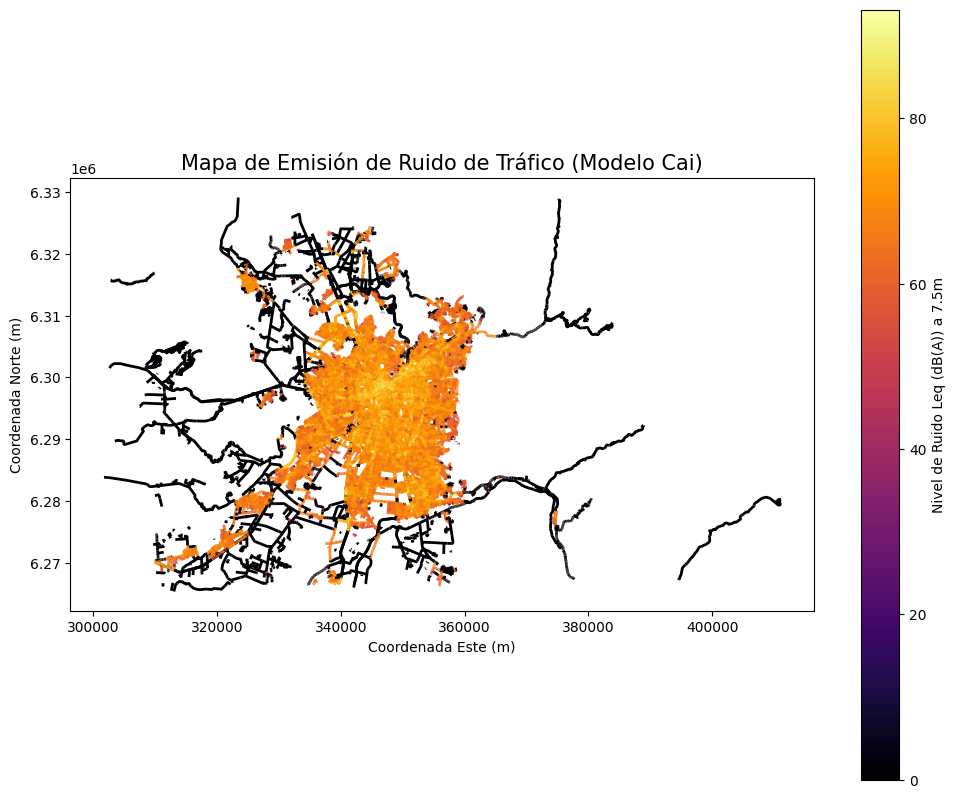

In [6]:
PORC_LIGEROS = 0.95
PORC_PESADOS = 0.05

R0 = 7.5  # metros

def modelo_emision_cai(row):
    """
    Calcula el Leq a 7.5m del eje de la vía basándose en velocidad y densidad.
    Implementa Ecuaciones 14 y 36 del documento.
    """
    v = row['velocidad_op']
    k = row['densidad_k']
    
    if v < 1 or k < 0.1:
        return 0
    
    # Ligeros
    l0_light = 33.66 * np.log10(v) + 12.60
    # Pesados
    l0_heavy = 38.10 * np.log10(v) + 18.00
        
    k_light = k * PORC_LIGEROS
    k_heavy = k * PORC_PESADOS
    
    leq_light = l0_light + 10 * np.log10(k_light) if k_light > 0 else 0
    leq_heavy = l0_heavy + 10 * np.log10(k_heavy) if k_heavy > 0 else 0
    
    suma_energia = (10**(leq_light/10)) + (10**(leq_heavy/10))
    leq_total = 10 * np.log10(suma_energia)
    
    return leq_total

print("Calculando Niveles de Ruido (Leq) por tramo...")
red_vial_final['ruido_leq'] = red_vial_final.apply(modelo_emision_cai, axis=1)

# -VISUALIZACION

print("\n5 Tramos con Mayor Emisión de Ruido [dB(A)]")
display(red_vial_final[['name', 'velocidad_op', 'densidad_k', 'ruido_leq']].sort_values(by='ruido_leq', ascending=False).head())

# Mapa de Calor Acustico
fig, ax = plt.subplots(figsize=(12, 10))
red_vial_final.plot(column='ruido_leq', 
                    ax=ax, 
                    legend=True,
                    cmap='inferno', 
                    legend_kwds={'label': "Nivel de Ruido Leq (dB(A)) a 7.5m"},
                    linewidth=2)

ax.set_title("Mapa de Emisión de Ruido de Tráfico (Modelo Cai)", fontsize=15)
ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")
plt.show()

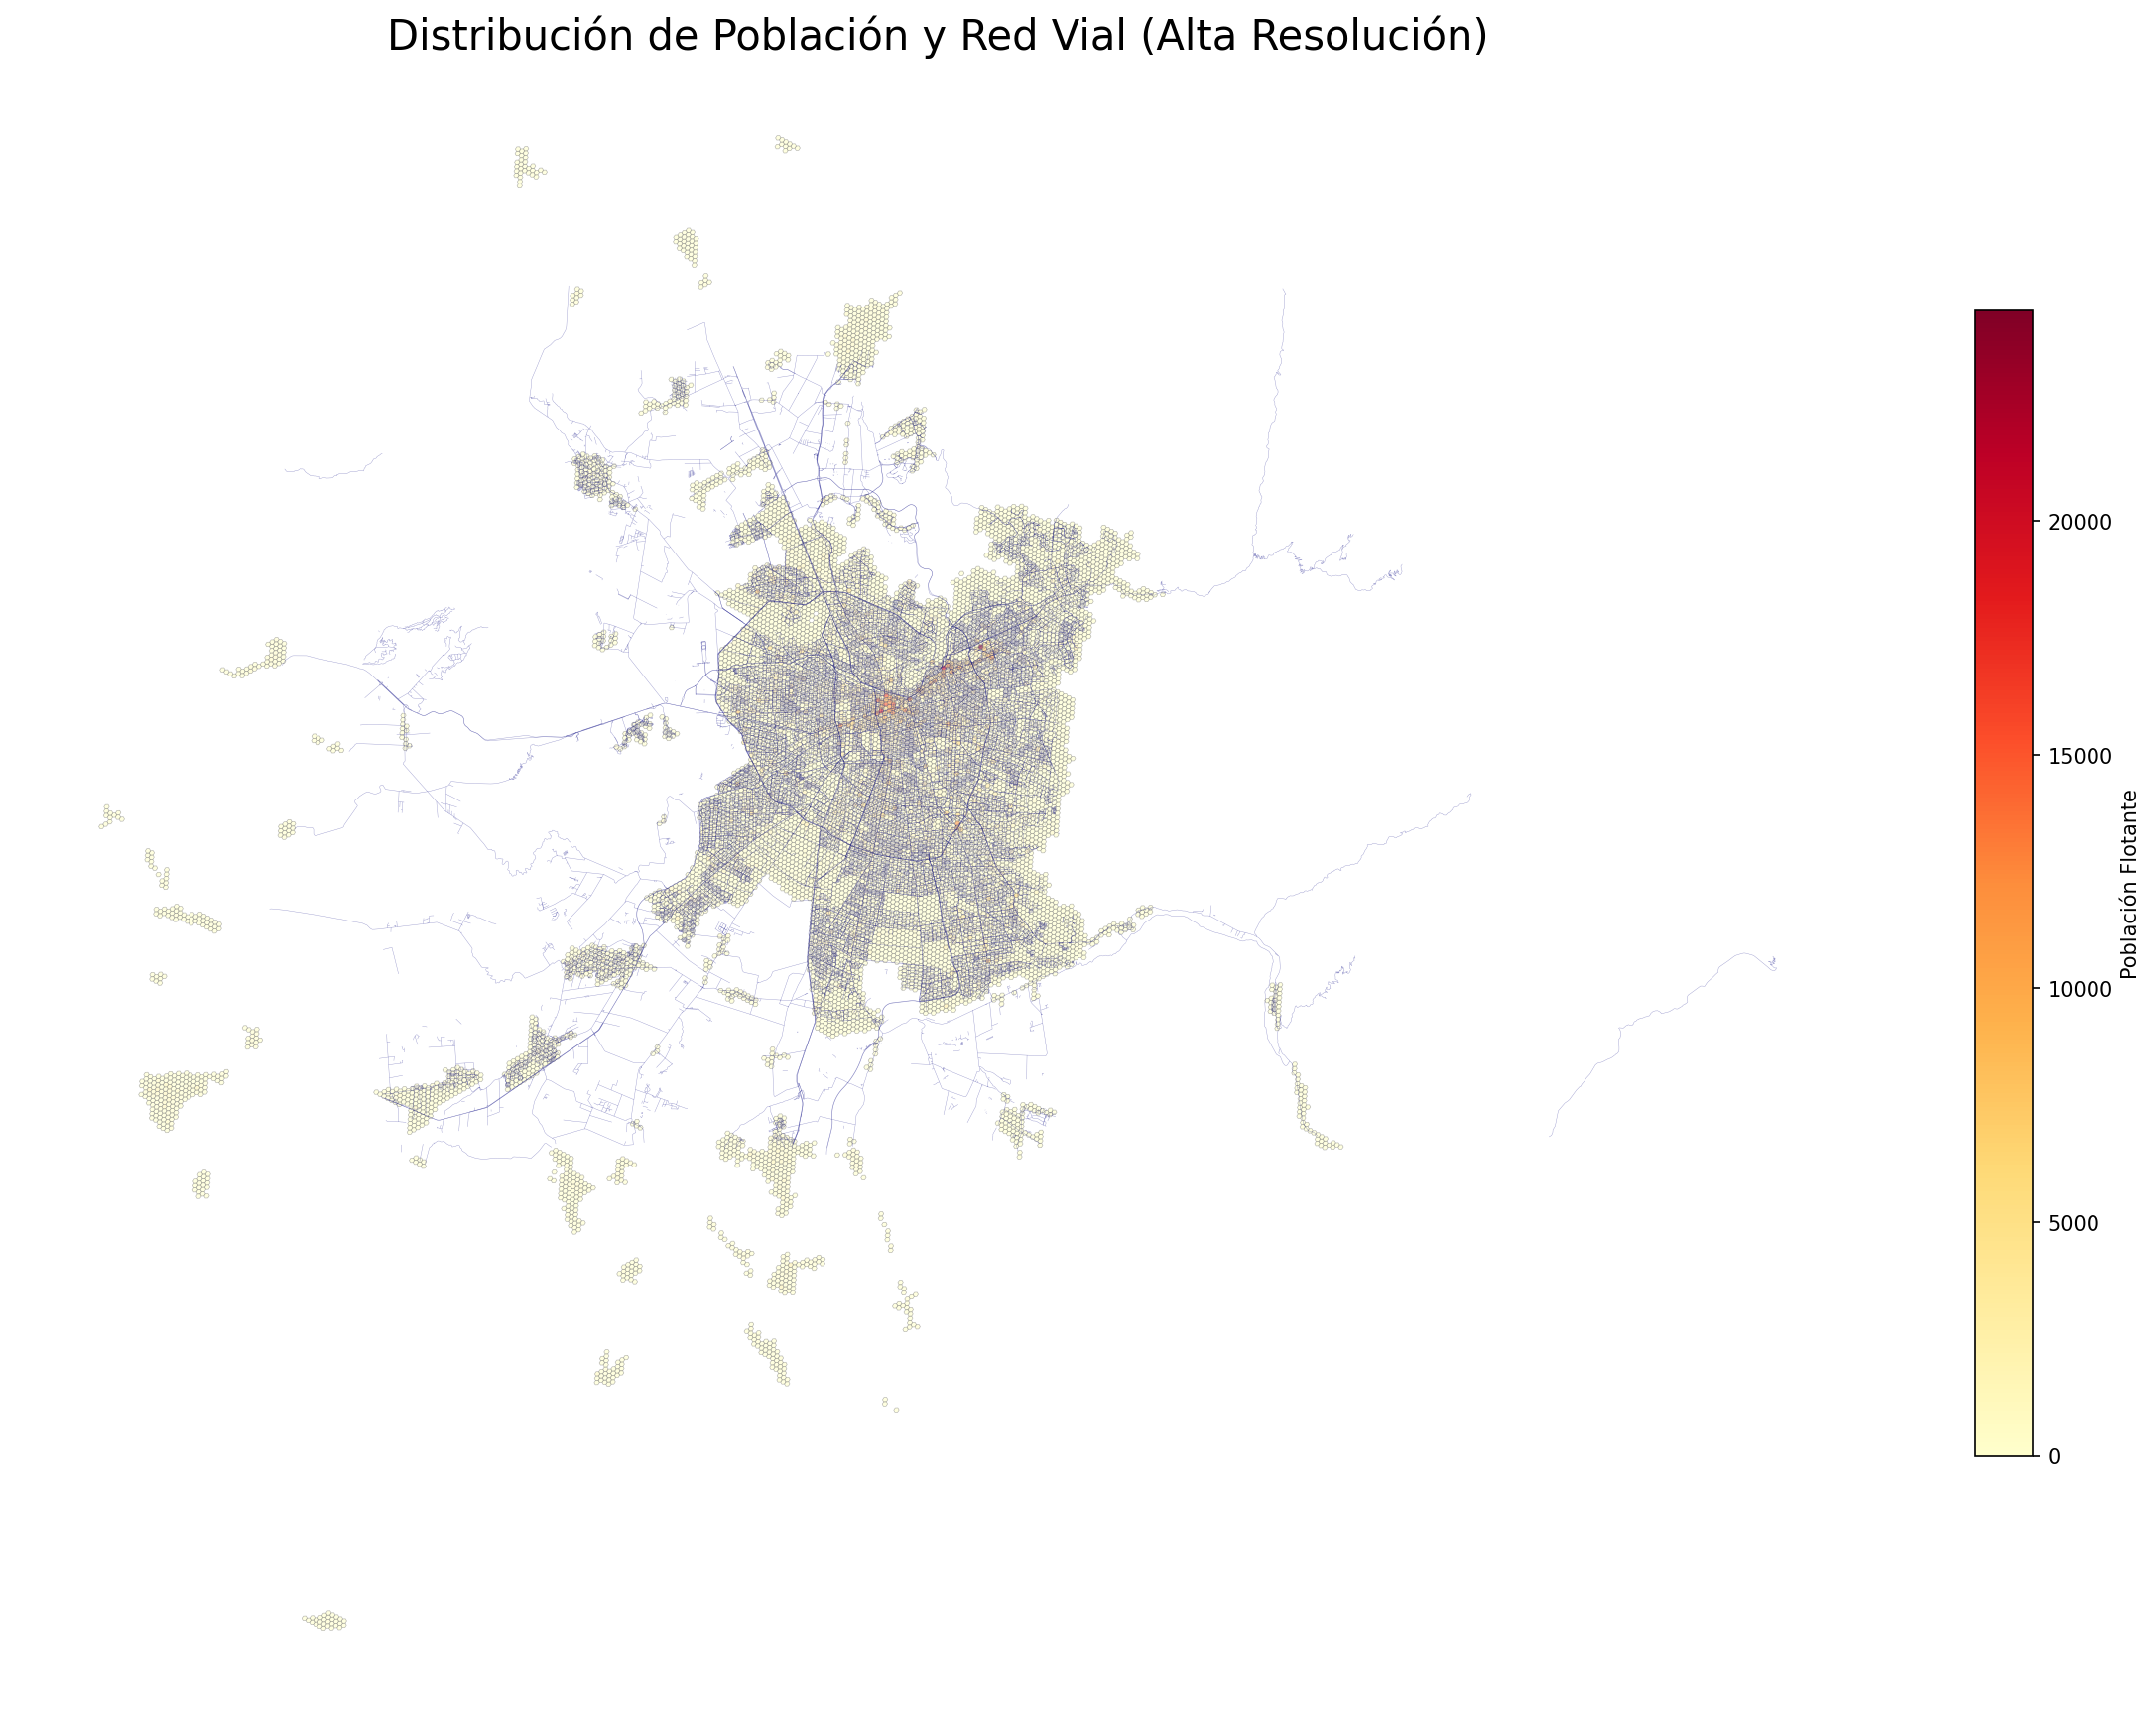

In [7]:
df_movilidad = pd.read_csv(Path(ruta) / 'data' / 'miercoles_rm.csv')

hora_target = 18
df_hex = df_movilidad[df_movilidad['hora'] == hora_target].copy()

def crear_hexagono(h3_index):
    try:
        boundary = h3.cell_to_boundary(h3_index)
        poly_points = [(lon, lat) for lat, lon in boundary]
        return Polygon(poly_points)
    except:
        return None

df_hex['geometry'] = df_hex['h3_9'].apply(crear_hexagono)
gdf_hex = gpd.GeoDataFrame(df_hex, geometry='geometry', crs="EPSG:4326")

if 'red_vial' in locals():
    gdf_hex = gdf_hex.to_crs(red_vial.crs)

fig, ax = plt.subplots(figsize=(20, 20), dpi=150)

gdf_hex.plot(
    column='poblacion_flotante',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    alpha=0.6,
    edgecolor='grey',
    linewidth=0.3,
    legend_kwds={'label': "Población Flotante", 'shrink': 0.5}
)

if 'red_vial' in locals():
    red_vial.plot(
        ax=ax, 
        color='navy', 
        linewidth=0.2, 
        alpha=0.4
    )

ax.set_title("Distribución de Población y Red Vial (Alta Resolución)", fontsize=20)
ax.axis('off') # Quitar ejes para que se vea limpio

plt.show()

In [8]:
m_hex = gdf_hex.explore(
    column='poblacion_flotante',
    cmap='YlOrRd',
    style_kwds={
        'stroke': True,
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.6
    },
    legend=True,
    tooltip=['h3_9', 'poblacion_flotante'],
    name="Población Flotante (H3)"
)

if 'red_vial' in locals():
    m_hex = red_vial.explore(
        m=m_hex,
        color='blue',
        style_kwds={'weight': 1},
        name="Red Vial",
        tooltip=['name']
    )

m_hex.save(Path(ruta) / 'data' / 'data_generada' / 'm_hex.html')

In [10]:
print("Preparando intersección geométrica (Corte de calles por hexágonos)...")

cols_vial = ['ruido_leq', 'geometry']
cols_zona = ['h3_9', 'poblacion_flotante', 'geometry']

vias_en_hex = gpd.overlay(
    red_vial_final[cols_vial], 
    gdf_zonas[cols_zona], 
    how='intersection'
)

vias_en_hex['longitud_segmento'] = vias_en_hex.length

print(f"   Generados {len(vias_en_hex)} segmentos de vía dentro de los hexágonos.")

print("2. Calculando ruido promedio energético por zona...")

def promedio_energetico(df_grupo):
    """
    Calcula el Leq promedio ponderado por longitud del tramo.
    Formula: 10 * log10( Sum(Li * 10^(Leq/10)) / Sum(Li) )
    """
    if df_grupo.empty or df_grupo['longitud_segmento'].sum() == 0:
        return 0
    
    energia = 10 ** (df_grupo['ruido_leq'] / 10)
    
    longitud_total = df_grupo['longitud_segmento'].sum()
    energia_ponderada = (energia * df_grupo['longitud_segmento']).sum() / longitud_total
    
    return 10 * np.log10(energia_ponderada)

stats_hex = vias_en_hex.groupby('h3_9').apply(
    lambda x: pd.Series({
        'ruido_ambiental_leq': promedio_energetico(x),
        'ruido_max': x['ruido_leq'].max(),
        'longitud_vias_km': x['longitud_segmento'].sum() / 1000
    })
)

hex_resultados = gdf_zonas.merge(stats_hex, on='h3_9', how='left')

hex_resultados['ruido_ambiental_leq'] = hex_resultados['ruido_ambiental_leq'].fillna(40)
hex_resultados['ruido_max'] = hex_resultados['ruido_max'].fillna(40)

umbral_molestia = 65
hex_resultados['poblacion_expuesta_critica'] = np.where(
    hex_resultados['ruido_ambiental_leq'] > umbral_molestia,
    hex_resultados['poblacion_flotante'],
    0
)

hex_resultados['indice_riesgo'] = hex_resultados['ruido_ambiental_leq'] * np.log1p(hex_resultados['poblacion_flotante'])

print("Análisis por hexágonos completado.")
display(hex_resultados[['h3_9', 'poblacion_flotante', 'ruido_ambiental_leq', 'poblacion_expuesta_critica']].sort_values(by='ruido_ambiental_leq', ascending=False).head())

m_ruido = hex_resultados.explore(
    column='ruido_ambiental_leq',
    cmap='inferno',
    style_kwds={'fillOpacity': 0.7, 'weight': 0.1},
    legend=True,
    name="Ruido Ambiental Leq (dB)",
    tooltip=['h3_9', 'ruido_ambiental_leq', 'poblacion_flotante', 'poblacion_expuesta_critica']
)
m_ruido.save(Path(ruta) / 'data' / 'data_generada' / 'm_ruido.html')

Preparando intersección geométrica (Corte de calles por hexágonos)...
   Generados 76449 segmentos de vía dentro de los hexágonos.
2. Calculando ruido promedio energético por zona...
Análisis por hexágonos completado.


C:\Users\Nicolas\AppData\Local\Temp\ipykernel_13200\3434793453.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_hex = vias_en_hex.groupby('h3_9').apply(


,h3_9,poblacion_flotante,ruido_ambiental_leq,poblacion_expuesta_critica
4960,89b2c556817ffff,19696.937500,88.648183,19696.937500
9913,89b2c50938bffff,8387.387947,87.617443,8387.387947
4738,89b2c554163ffff,10851.002500,86.539148,10851.002500
876,89b2c55416fffff,3198.069835,85.802001,3198.069835
872,89b2c554133ffff,11640.312500,85.625805,11640.312500


In [11]:
m_riesgo = hex_resultados.explore(
    column='indice_riesgo',
    cmap='Reds',
    style_kwds={
        'fillOpacity': 0.8,
        'weight': 0.2, 
        'color': 'black'
    },
    legend=True,
    legend_kwds={'caption': 'Índice de Riesgo (Ruido x Población)'},
    name="Mapa de Riesgo Acústico",
    tooltip=[
        'h3_9', 
        'ruido_ambiental_leq',
        'poblacion_flotante', 
        'indice_riesgo',
        'poblacion_expuesta_critica'
    ]
)

if 'red_vial_final' in locals():
    vias_criticas = red_vial_final[red_vial_final['ruido_leq'] > 70]
    
    m_riesgo = vias_criticas.explore(
        m=m_riesgo,
        column='ruido_leq',
        cmap='inferno',
        style_kwds={'weight': 2},
        name="Vías Críticas (>70 dB)",
        tooltip=['name', 'ruido_leq']
    )

m_riesgo.save(Path(ruta) / 'data' / 'data_generada' / 'm_riesgo.html')

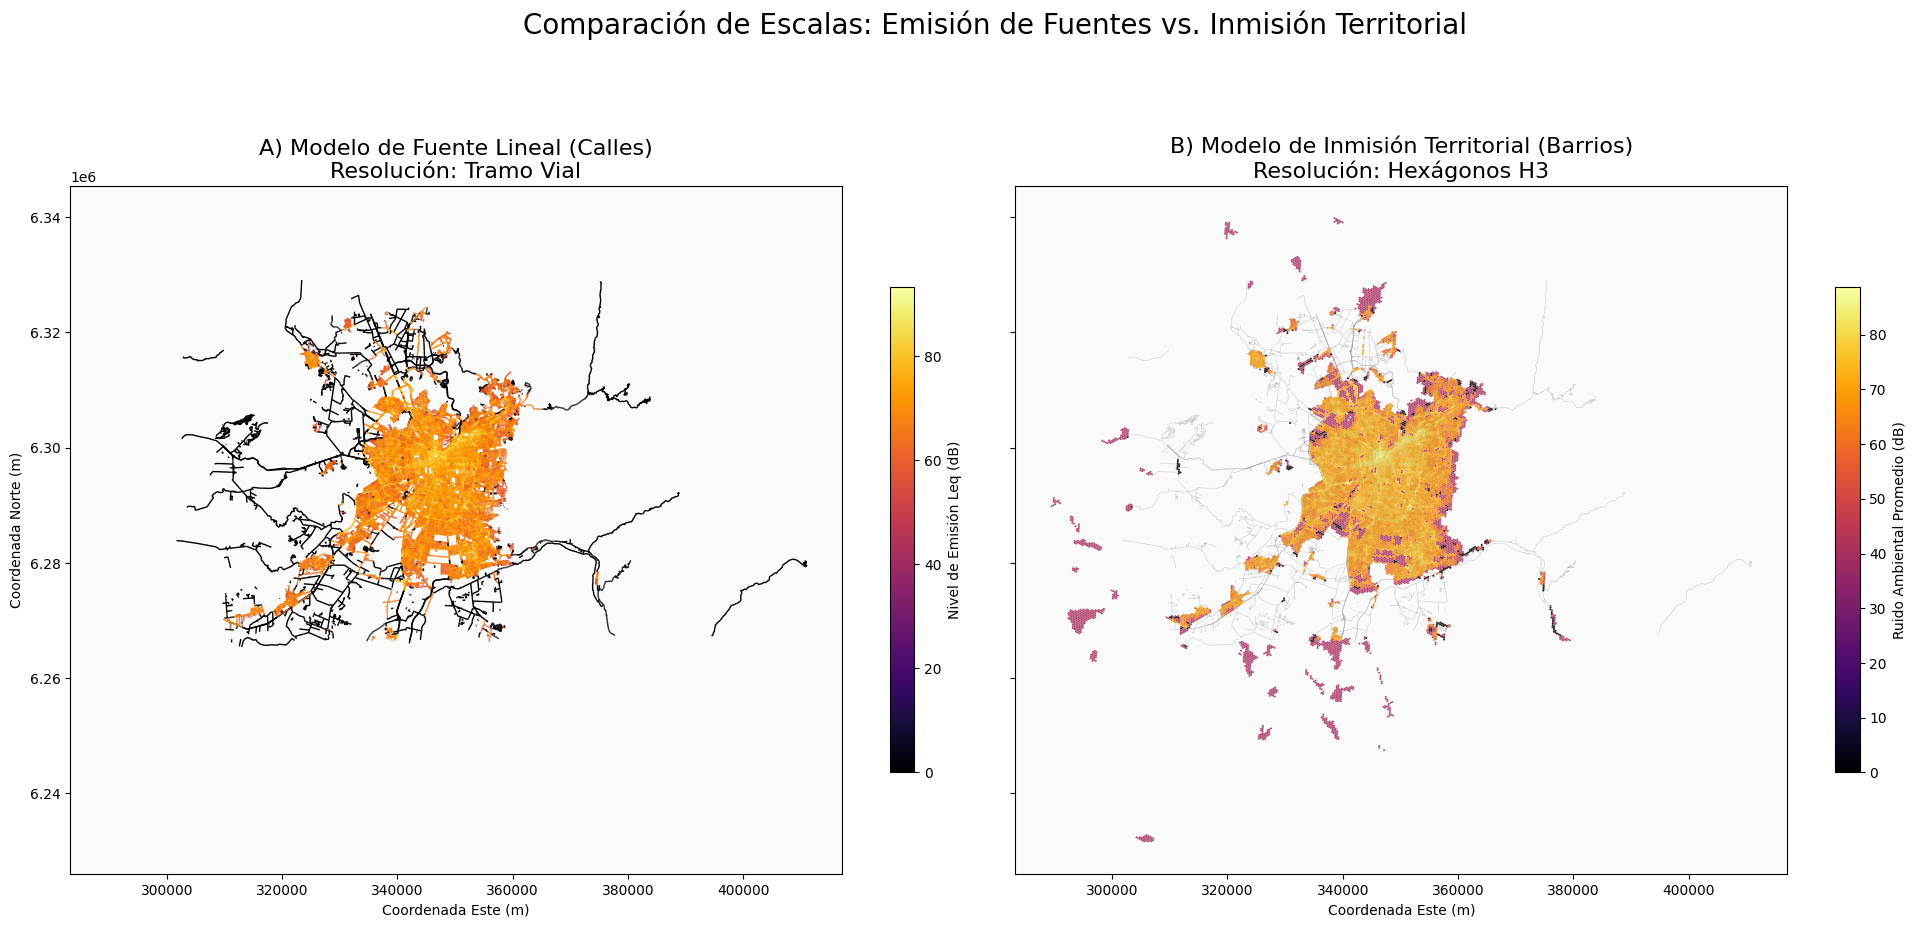

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

red_vial_final.plot(
    column='ruido_leq',
    ax=ax1,
    cmap='inferno',
    linewidth=1,
    legend=True,
    legend_kwds={'label': "Nivel de Emisión Leq (dB)", 'shrink': 0.5}
)
ax1.set_title("A) Modelo de Fuente Lineal (Calles)\nResolución: Tramo Vial", fontsize=16)
ax1.set_facecolor('#fafafa') 
ax1.set_xlabel("Coordenada Este (m)")
ax1.set_ylabel("Coordenada Norte (m)")

red_vial_final.plot(
    ax=ax2,
    color='gray',
    linewidth=0.5,
    alpha=0.3,
    zorder=1
)

hex_resultados.plot(
    column='ruido_ambiental_leq',
    ax=ax2,
    cmap='inferno', 
    alpha=0.85,
    edgecolor='none',
    zorder=2, 
    legend=True,
    legend_kwds={'label': "Ruido Ambiental Promedio (dB)", 'shrink': 0.5}
)

ax2.set_title("B) Modelo de Inmisión Territorial (Barrios)\nResolución: Hexágonos H3", fontsize=16)
ax2.set_facecolor('#fafafa')
ax2.set_xlabel("Coordenada Este (m)")

plt.tight_layout()
plt.suptitle("Comparación de Escalas: Emisión de Fuentes vs. Inmisión Territorial", fontsize=20, y=1.02)

plt.savefig(Path(ruta) / 'data' / 'data_generada' / 'Comparacion_Modelos_Ruido.png', dpi=300, bbox_inches='tight')

plt.show()

In [15]:
print("Generando mapa comparativo")

m_dual = folium.plugins.DualMap(location=[-33.45, -70.65], zoom_start=12, prefer_canvas=True)

red_vial_final.explore(
    m=m_dual.m1,
    column='ruido_leq',
    cmap='inferno',
    style_kwds={'weight': 2},
    tooltip=['name', 'ruido_leq', 'velocidad_op'],
    name="Emisión Calles"
)

hex_resultados.explore(
    m=m_dual.m2,
    column='ruido_ambiental_leq',
    cmap='inferno',
    style_kwds={'fillOpacity': 0.7, 'weight': 0},
    tooltip=['h3_9', 'ruido_ambiental_leq', 'poblacion_flotante'],
    name="Ruido Zonal"
)

folium.LayerControl(collapsed=False).add_to(m_dual)

m_dual.save(Path(ruta) / 'data' / 'data_generada' / 'm_comparativo_dual.html')
print("Mapa comparativo guardado como 'm_comparativo_dual.html'")

Generando mapa comparativo
Mapa comparativo guardado como 'm_comparativo_dual.html'


In [ ]:
print("mapa interactivo LIGERO")

red_light = red_vial_final.copy()
red_light['geometry'] = red_light.simplify(tolerance=5)
red_light = red_light[red_light['ruido_leq'] > 45]

hex_light = hex_resultados.copy()
hex_light['geometry'] = hex_light.simplify(tolerance=2)

m_dual_light = folium.plugins.DualMap(
    location=[-33.45, -70.65], 
    zoom_start=12,
    tiles='CartoDB positron',
    prefer_canvas=True
)

red_light.explore(
    m=m_dual_light.m1,
    column='ruido_leq',
    cmap='inferno',
    style_kwds={'weight': 1.5},
    tooltip=['name', 'ruido_leq'],
    name="Emisión Calles (>45 dB)"
)

hex_light.explore(
    m=m_dual_light.m2,
    column='ruido_ambiental_leq',
    cmap='inferno',
    style_kwds={'fillOpacity': 0.6, 'weight': 0},
    tooltip=['h3_9', 'ruido_ambiental_leq', 'poblacion_flotante'],
    name="Ruido Zonal"
)

folium.LayerControl(collapsed=False).add_to(m_dual_light)

m_dual_light.save(Path(ruta) / 'data' / 'data_generada' / 'm_comparativo_dual_light.html')

Generando mapa interactivo LIGERO...


In [ ]:
%store gdf_zonas
%store red_vial_final